## Marchenko-based imaging using decomposed Green’s functions

### **Theoretical Expression for Marchenko Imaging**

The code below implements **Marchenko-based imaging** using **decomposed Green’s functions**, specifically the **upgoing Green’s function** $g^-$ and the **downgoing direct arrival** (approximated as $f_0^+$).

---

The **Marchenko zero-lag cross-correlation imaging condition** is represented by this:

$$
I(\mathbf{x}_f) = \sum_{\mathbf{x}_r} \int dt \, f_0^+(\mathbf{x}_f, \mathbf{x}_r, t) \cdot g^-(\mathbf{x}_r, \mathbf{x}_f, t)
$$

where:

* $I(\mathbf{x}_f)$ is the image at the **focusing location,** $\mathbf{x}_f$
* $f_0^+(\mathbf{x}_f, \mathbf{x}_r, t)$: This is the downgoing focusing function focused at the focal point. It is **time-reversed direct arrival** from the focal point to the receiver
* $g^-(\mathbf{x}_r, \mathbf{x}_f, t)$: **upgoing Green’s function** from the focal point to the receiver
* $\sum_{\mathbf{x}_r} \int dt$: summation over receivers and time
* The dot product implies **zero-lag temporal correlation**

This is equivalent to:

$$
I(\mathbf{x}_f) = \int_S \int_{-\infty}^{\infty} f_0^+(\mathbf{x}_f, \mathbf{x}_r, t) \cdot g^-(\mathbf{x}_r, \mathbf{x}_f, t) \, dt \, d\mathbf{x}_r
$$

#### Recall that downgoing focusing function $f_0^+$ :

$$
f_0^+(\mathbf{x}_f, \mathbf{x}_r, t) = T_d(\mathbf{x}_r, \mathbf{x}_f, -t)
$$

- Where:
  - $T_d$ = Direct arrival wavefield (one-way travel time) from the subsurface focusing point (virtual source) to the surface receivers
  - $T_d(\mathbf{x}_r, \mathbf{x}_f, -t)$ is read as the time-reversed direct arrival at the receiver location $\mathbf{x}_r$ from the virtual source $\mathbf{x}_f$ in the subsurface.
  - $\mathbf{x}_r$ = Receiver position
  - $\mathbf{x}_f$ = Focal point position
- Implementation: Time reversal of direct arrival (Time-reversed direct arrival)

So,

$$
I(\mathbf{x}_f) = \int_S \int_{-\infty}^{\infty} f_0^+(\mathbf{x}_f, \mathbf{x}_r, t) \cdot g^-(\mathbf{x}_r, \mathbf{x}_f, t) \, dt \, d\mathbf{x}_r
$$

$$
I(\mathbf{x}_f) = \int_S \int_{-\infty}^{\infty} T_d(\mathbf{x}_r, \mathbf{x}_f, -t) \cdot g^-(\mathbf{x}_r, \mathbf{x}_f, t) \, dt \, d\mathbf{x}_r
$$

---

### Interpretation

This imaging condition is a **cross-correlation-type condition**, but instead of using raw reflection data, it uses the **Marchenko-retrieved upgoing Green’s function** $g^-$, which **includes multiple scattering** from below the focal point. It is coupled with the **direct arrival** to efficiently image **reflectors at position $\mathbf{x}_f$**. It is simply a zero-lag cross-correlation between the time-reversed direct arrival and the retrieved upgoing Green’s function, summed over all receivers.


In [1]:
"""
Marchenko Imaging using Marchenko Green's Functions
Optimized for Google Colab NVIDIA T4 GPU using CuPy.

This script loops over a spatial grid of subsurface points (x, z).
For each point, it computes the direct arrival, iteratively solves for the
Marchenko Green's functions on the GPU, and applies the imaging condition
to build an artifact-free subsurface image.
"""

import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import os
from scipy import signal
from scipy.io import loadmat
from scipy.signal.windows import tukey
from tqdm.notebook import tqdm  # Notebook-friendly progress bar
from google.colab import drive

# Mount Google Drive
drive.mount("/content/drive", force_remount=True)

# Setup directories (Update this path to match your exact Drive structure)
base_dir = '/content/drive/MyDrive/Marchenko'
mat_dir  = os.path.join(base_dir, 'DATA', 'MAT')

# Create a local output directory in Colab to save the PNGs
out_dir  = '/content/Marchenko_Outputs'
os.makedirs(out_dir, exist_ok=True)

print("Environment configured and directories set!")

Mounted at /content/drive
Environment configured and directories set!


### Data Dimension

In [2]:
print(np.shape(loadmat(os.path.join(mat_dir, 'ICCR_marchenko_R.mat'))["sg"]))        # (3001, 188, 188)
print(np.shape(loadmat(os.path.join(mat_dir, 'ICCR_marchenko_eik.mat'))["eik"]))     # (201, 375, 188)

print(np.shape(loadmat(os.path.join(mat_dir, 'ICCR_marchenko_TD.mat'))['td']))       # (3001, 188)
print(np.shape(loadmat(os.path.join(mat_dir, 'ICCR_marchenko_theta.mat'))['theta'])) # (3001, 188)
print(np.shape(loadmat(os.path.join(mat_dir, 'ICCR_marchenko_GT.mat'))['gt']))       # (3001, 188)

(3001, 188, 188)
(201, 375, 188)
(3001, 188)
(3001, 188)
(3001, 188)


### Compute the direct arrival and filter for Marchenko implementation.

CPU-based direct arrival calculator

In [3]:
def marchenko_direct(tt, wav, ns, ts, dt, freq):
    """
    Calculates the initial direct arrival and the time-symmetric causality filter (CPU).

    Parameters:
        tt (array_like): 1D array of travel times from Eikonal solver.
        wav (array_like): 1D source wavelet array.
        ns (int): Number of surface receivers.
        ts (int): Number of time samples.
        dt (float): Time sampling interval in seconds.
        freq (float): Wavelet frequency.

    Returns:
        direct (ndarray): 2D direct arrival wavefield.
        filter_array (ndarray): 2D causality mute filter.
    """
    ts_half = int(np.floor(ts / 2)) + 1
    direct = np.zeros((ts_half, ns))

    # Generate impulses at eikonal travel times with spherical divergence scaling
    # Assign offset-dependent direct arrival amplitude
    for idx in range(ns):
        # Convert travel time to sample index (0-based)
        sample_index = int(round(tt[idx] / dt))
        # Ensure index is within valid range before assignment
        if 0 <= sample_index < ts_half:   # Ensure index is within bounds
            direct[sample_index, idx] = np.sqrt(1.0 / tt[idx])

    # Convolve each direct arrival trace with the input wavelet
    for i in range(ns):
        direct[:, i] = signal.convolve(direct[:, i], wav.flatten(), mode='same')

    # Build causality filter based on travel times and wavelet clearance zone
    filter_array = np.zeros((ts, ns))        # Initialize filter array (non-negative times)

    # Calculate filter parameters. # Calculate filter locations based on travel times
    loc = (np.ceil(ts / 2) + np.round(tt / dt)).astype(int)

    # Define clearance zone length around arrival in number of samples for the filter taper region
    wl  = int(round((2 * np.sqrt(3 / 2) / (np.pi * freq)) / dt))

    # Build the offset-dependent mute filter
    for idx in range(ns):
        # Set filter to 1 before the clearance zone
        # Calculate index where filter value of 1 ends (start of taper)
        end_ones = loc[idx] - wl

        # Set filter to 1 for samples before the taper region (mute off)
        if end_ones > 0:     # Only set if within bounds
            filter_array[:end_ones, idx] = 1

        # Apply linear taper in the clearance zone
        taper_start     = end_ones
        taper_start_idx = max(taper_start - 1, 0)
        taper_end_idx   = min(taper_start + 5, ts)

        # Set taper values if within bounds
        # Apply linear taper from 1 down to 0 over 6 samples (or fewer near edges)
        if taper_start_idx < ts:
            n_taper    = taper_end_idx - taper_start_idx
            filter_array[taper_start_idx:taper_end_idx, idx] = np.linspace(1.0, 0.0, 6)[:n_taper]

    # Pad and symmetrize
    # Pad direct arrival with zeros for negative times
    zero_pad = np.zeros((int(np.floor(ts / 2)), ns))
    direct   = np.vstack((zero_pad, direct))

    # Make the filter symmetric in time by flipping second half and stacking
    top          = filter_array[int(np.ceil(ts / 2)):, :]      # Part above midpoint
    top          = np.flipud(top)                              # Flip vertically
    bottom       = filter_array[int(np.ceil(ts / 2)) - 1:, :]  # Part from midpoint onward
    filter_array = np.vstack((top, bottom))

    return direct, filter_array

### Green's Functions Computation Using Marchenko's Methods

The function computes the Green's function from the iterative focusing function starting with an initial estimate from the direct arrival.

Massively parallelized GPU iterative solver.

In [4]:
def marchenko_green_function_gpu(direct, filter_array, sg, nitr):
    """
    Iteratively solves the Marchenko equations to retrieve Green's Functions (GPU).

    Parameters:
        direct (cupy.ndarray): Direct arrival transferred to VRAM.
        filter_array (cupy.ndarray): Causality filter transferred to VRAM.
        sg (cupy.ndarray): Frequency-domain reflectivity matrix.
        nitr (int): Number of Marchenko iterations.

    Returns:
        g_minus (cupy.ndarray): Upgoing Green's function.
        (Note: g_plus and g_total calculations are bypassed here to maximize
         imaging speed, as the imaging condition only requires g_minus).
    """
    # Initialize focusing functions
    f0_plus_freq = cp.fft.fft(cp.flipud(direct), axis=0)
    f0_minus = cp.sum(sg * f0_plus_freq[:, cp.newaxis, :], axis=2)

    f0_minus_time          = cp.real(cp.fft.ifft(f0_minus, axis=0))
    f0_minus_time_shift    = cp.fft.ifftshift(f0_minus_time, axes=0)
    f0_minus_time_windowed = filter_array * f0_minus_time_shift

    fk_minus_tr   = cp.fft.fft(cp.flipud(f0_minus_time_windowed), axis=0)
    f0_minus_freq = cp.fft.fft(f0_minus_time_windowed, axis=0)

    # Iterative updates
    for _ in range(nitr):
        mk_plus = cp.sum(sg * fk_minus_tr[:, cp.newaxis, :], axis=2)
        mk_plus_time          = cp.real(cp.fft.ifft(mk_plus, axis=0))
        mk_plus_time_shift    = cp.fft.ifftshift(mk_plus_time, axes=0)
        mk_plus_time_windowed = filter_array * mk_plus_time_shift
        mk_plus_freq          = cp.fft.fft(cp.flipud(mk_plus_time_windowed), axis=0)

        fk_minus  = cp.sum(sg * mk_plus_freq[:, cp.newaxis, :], axis=2)
        fk_minus_time       = cp.real(cp.fft.ifft(fk_minus, axis=0))
        fk_minus_time_shift = cp.fft.ifftshift(fk_minus_time, axes=0)

        part1 = cp.real(cp.fft.ifft(f0_minus_freq, axis=0))
        fk_minus_time_windowed = filter_array * (part1 + fk_minus_time_shift)

        fk_minus_tr   = cp.fft.fft(cp.flipud(fk_minus_time_windowed), axis=0)
        fk_minus_freq = cp.fft.fft(fk_minus_time_windowed, axis=0)

    fk_plus_freq = f0_plus_freq + mk_plus_freq

    # Calculate strictly the Upgoing Green's function (G-) for the imaging condition
    g_minus_freq       = cp.sum(sg * fk_plus_freq[:, cp.newaxis, :], axis=2)
    g_minus_time       = cp.real(cp.fft.ifft(g_minus_freq, axis=0))
    g_minus_time_shift = cp.fft.ifftshift(g_minus_time, axes=0)
    g_minus            = -cp.real(cp.fft.ifft(fk_minus_freq, axis=0)) + g_minus_time_shift

    # Downgoing Green's function
    # g_plus: downgoing response from fk_minus_tr (this is same as time reversed f0_minus_freq)
    g_plus_freq        = cp.sum(sg * fk_minus_tr[:, cp.newaxis, :], axis=2)
    g_plus_time        = cp.real(cp.fft.ifft(g_plus_freq, axis=0))
    g_plus_time_shift  = cp.fft.ifftshift(g_plus_time, axes=0)
    g_plus             = cp.flipud(cp.real(cp.fft.ifft(fk_plus_freq, axis=0))) - g_plus_time_shift

    g_total = g_minus + g_plus

    #-----------------
    # Post Processing
    #-----------------
    # Normalize and Mute
    max_amp = cp.max(cp.abs(g_total))
    if max_amp > 0:
        g_minus = (g_minus / max_amp) * (1 - filter_array)
        g_plus  = (g_plus  / max_amp) * (1 - filter_array)
        g_total = (g_total / max_amp) * (1 - filter_array)

    # Convert focusing functions to time domain and normalize
    f0_plus_time  = np.real(np.fft.ifft(f0_plus_freq, axis=0))
    f0_minus_time = np.real(np.fft.ifft(f0_minus_freq, axis=0))
    fk_plus_time  = np.real(np.fft.ifft(fk_plus_freq, axis=0))
    fk_minus_time = np.real(np.fft.ifft(fk_minus_freq, axis=0))

    fk_plus_max    = np.max(np.abs(fk_plus_time))
    if fk_plus_max > 0:
        f0_plus_time  /= fk_plus_max
        f0_minus_time /= fk_plus_max
        fk_minus_time /= fk_plus_max
        fk_plus_time  /= fk_plus_max

    return g_minus, g_plus, g_total

### Execution, Imaging Loop & Plotting

This cell handles data loading, executes the nested loop over the spatial grid evaluating the zero-lag cross-correlation imaging condition ($I(\mathbf{x}_f) = \sum f_0^+ \cdot g^-$), and outputs the results.


Loading data from Drive...
Transferring core arrays to GPU...
Executing Marchenko Imaging across 2496 grid points...


Processing X-lines:   0%|          | 0/64 [00:00<?, ?it/s]


Rendering and saving figures...
Saved: /content/Marchenko_Outputs/01_Velocity_Model_Area.png


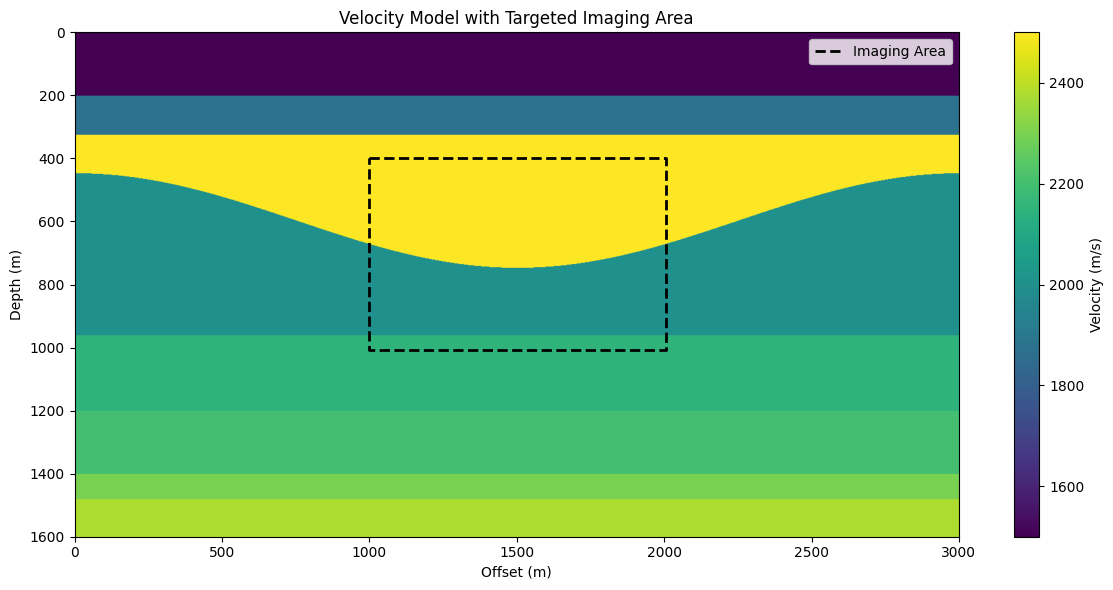

Saved: /content/Marchenko_Outputs/02_Marchenko_Image_Full.png


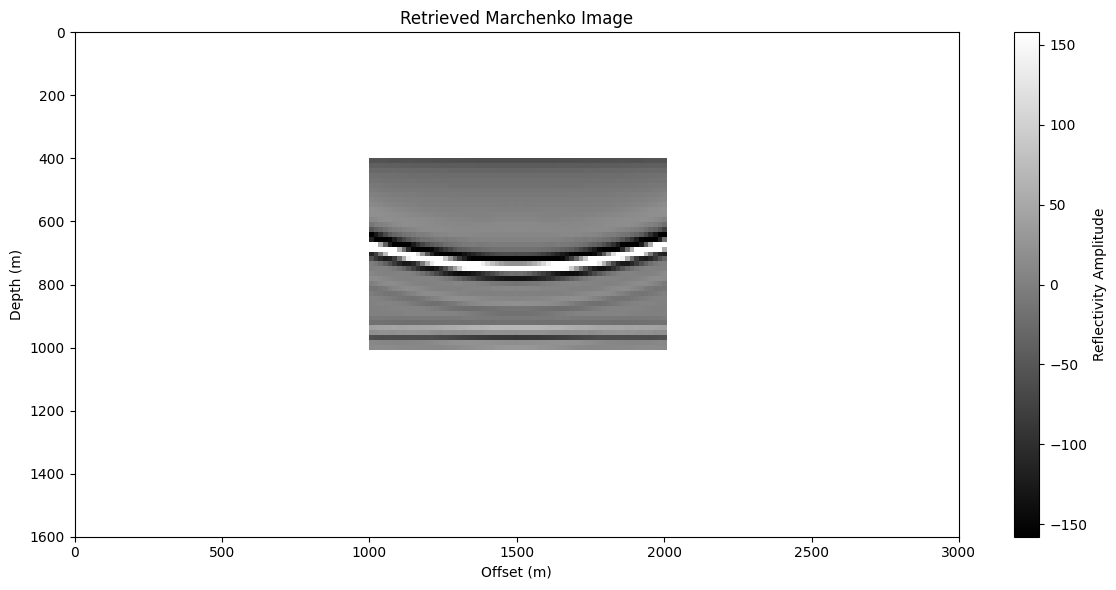

Saved: /content/Marchenko_Outputs/03_Marchenko_Image_Zoomed.png


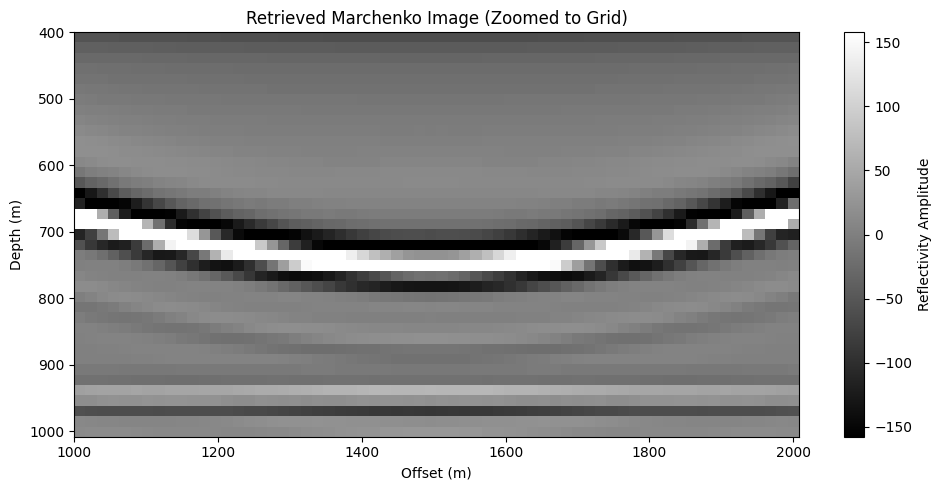

Processing complete!


In [6]:
# --------------------------------
# 1) USER INPUT - SETUP VARIABLES
# --------------------------------
nitr     = 3                         # Number of Marchenko iterations
tp       = 0.2                       # Taper fraction for receiver array
scaling  = 1                         # Scaling factor for reflectivity
sp       = 16                        # Image point spacing (m)
# x_pos    = np.arange(400, 2500 + 1, sp)  # X positions of image points
# z_pos    = np.arange(200, 1600 + 1, sp)  # Z positions of image points

x_pos   = np.arange(1000, 2000 + sp, sp)  # Grid of X coordinates to image
z_pos   = np.arange(400, 1000 + sp, sp)  # Grid of Z coordinates to image

# Full grid mapping based on Eikonal boundaries
# x_pos    = np.arange(0, 2992 + 1, sp)  # 0 to 2992m
# z_pos    = np.arange(0, 1600 + 1, sp)  # 0 to 1600m

dxm      = 8                         # Grid spacing for eikonal solution
dt       = 0.002                     # Time sampling (s)
dx       = 16                        # Receiver spacing (m)
o_min    = 4                         # Initial receiver offset (m)
freq     = 20                        # Ricker wavelet frequency (Hz)

# -------------
# 2) LOAD DATA
# -------------
print("Loading data from Drive...")
try:
    sg  = loadmat(os.path.join(mat_dir, 'ICCR_marchenko_R.mat'))['sg'].astype(np.float32)
    eik = loadmat(os.path.join(mat_dir, 'ICCR_marchenko_eik.mat'))['eik'].astype(np.float32)
    wav = loadmat(os.path.join(mat_dir, 'ICCR_marchenko_wav.mat'))['wav'].flatten().astype(np.float32)
    vel = loadmat(os.path.join(mat_dir, 'ICCR_marchenko_vel.mat'))['vel'].astype(np.float32)
except FileNotFoundError as e:
    print(f"Error loading data: {e}\nPlease check your Drive paths.")
    raise

# -------------------------------------------
# 3) AUTOMATICALLY DEFINED - SETUP VARIABLES
# -------------------------------------------
ns    = sg.shape[1]
ts    = sg.shape[0]

# Apply spatial taper (Tukey window) on CPU
tap = tukey(ns, tp).astype(np.float32)
sg *= tap[np.newaxis, :]

# Transfer Reflectivity to GPU and transform to frequency domain ONCE outside the loop
print("Transferring core arrays to GPU...")
sg_gpu     = cp.asarray(sg, dtype=cp.float32)
sg_fft_gpu = cp.fft.fft(sg_gpu * (-2 * dt * dx * scaling), axis=0)

# -------------------------------
# 4) MARCHENKO IMAGING GRID LOOP
# -------------------------------
img = np.zeros((len(x_pos), len(z_pos)))  # Initialize image matrix

total_points = len(x_pos) * len(z_pos)
print(f"Executing Marchenko Imaging across {total_points} grid points...")

# Loop over the spatial grid
for xidx in tqdm(range(len(x_pos)), desc="Processing X-lines"):
    for zidx in range(len(z_pos)):
        x, z = x_pos[xidx], z_pos[zidx]
        x_idx, z_idx = int(round(x/dxm)), int(round(z/dxm))

        # Extract travel times
        tt = eik[z_idx, x_idx, :].flatten()

        # CPU: Fast calculation of direct arrival and filter
        direct_cpu, filter_cpu = marchenko_direct(tt, wav, ns, ts, dt, freq)

        # GPU Transfer
        direct_gpu = cp.asarray(direct_cpu, dtype=cp.float32)
        filter_gpu = cp.asarray(filter_cpu, dtype=cp.float32)

        # GPU: Iterative Green's Function retrieval
        g_minus_gpu, g_plus_gpu, g_total_gpu = marchenko_green_function_gpu(direct_gpu, filter_gpu, sg_fft_gpu, nitr)

        # IMAGING CONDITION: Zero-lag temporal cross-correlation
        # Summing the element-wise multiplication collapses the wavefield into a single pixel.
        img[xidx, zidx] = cp.sum(direct_gpu * g_minus_gpu).get()

# ----------------------------
# 5) VISUALIZATION AND SAVING
# ----------------------------
print("\nRendering and saving figures...")
vmax = 0.5 * np.max(np.abs(img))
img_extent = [x_pos.min(), x_pos.max(), z_pos.max(), z_pos.min()]
vel_extent = [0, 3000, 1600, 0]

# FIGURE 1: Velocity Model with Imaging Area Overlay
fig1, ax1 = plt.subplots(figsize=(12, 6))
im1 = ax1.imshow(vel, extent=vel_extent, cmap='viridis', aspect='auto')
ax1.set_title('Velocity Model with Targeted Imaging Area')
ax1.set_xlabel('Offset (m)')
ax1.set_ylabel('Depth (m)')
fig1.colorbar(im1, ax=ax1, label='Velocity (m/s)')

# Draw the boundary rectangle of our imaged zone
rect_x = [x_pos.min(), x_pos.max(), x_pos.max(), x_pos.min(), x_pos.min()]
rect_z = [z_pos.min(), z_pos.min(), z_pos.max(), z_pos.max(), z_pos.min()]
ax1.plot(rect_x, rect_z, color='black', linestyle='--', linewidth=2, label='Imaging Area')
ax1.legend(loc='upper right')
ax1.set_xlim(0, 3000)
ax1.set_ylim(1600, 0)
plt.tight_layout()

fig1_path = os.path.join(out_dir, "01_Velocity_Model_Area.png")
plt.savefig(fig1_path, dpi=600, bbox_inches='tight')
print(f"Saved: {fig1_path}")
plt.show()

# FIGURE 2: Final Marchenko Image
fig2, ax2 = plt.subplots(figsize=(12, 6))
im2 = ax2.imshow(img.T, extent=img_extent, cmap='gray', vmin=-vmax, vmax=vmax, aspect='auto')
ax2.set_title('Retrieved Marchenko Image')
ax2.set_xlabel('Offset (m)')
ax2.set_ylabel('Depth (m)')
fig2.colorbar(im2, ax=ax2, label='Reflectivity Amplitude')

# Maintain macroscopic view matching the velocity model
ax2.set_xlim(0, 3000)
ax2.set_ylim(1600, 0)
plt.tight_layout()

fig2_path = os.path.join(out_dir, "02_Marchenko_Image_Full.png")
plt.savefig(fig2_path, dpi=600, bbox_inches='tight')
print(f"Saved: {fig2_path}")
plt.show()

# FIGURE 3: Zoomed Marchenko Image
fig3, ax3 = plt.subplots(figsize=(10, 5))
im3 = ax3.imshow(img.T, extent=img_extent, cmap='gray', vmin=-vmax, vmax=vmax, aspect='auto')
ax3.set_title('Retrieved Marchenko Image (Zoomed to Grid)')
ax3.set_xlabel('Offset (m)')
ax3.set_ylabel('Depth (m)')
fig3.colorbar(im3, ax=ax3, label='Reflectivity Amplitude')

# Zoomed limits
ax3.set_xlim(x_pos.min(), x_pos.max())
ax3.set_ylim(z_pos.max(), z_pos.min())
plt.tight_layout()

fig3_path = os.path.join(out_dir, "03_Marchenko_Image_Zoomed.png")
plt.savefig(fig3_path, dpi=600, bbox_inches='tight')
print(f"Saved: {fig3_path}")
plt.show()

print("Processing complete!")

### Key References

1. **Lomas, Angus**, and **Andrew Curtis**. "An introduction to Marchenko methods for imaging." *Geophysics* 84, no. 2 (2019): F35-F45. Download the paper [here](https://pubs.geoscienceworld.org/seg/geophysics/article/84/2/F35/569232/An-introduction-to-Marchenko-methods-for-imagingAn), and the original MATLAB code [here](https://wiki.seg.org/wiki/Software:Marchenko_for_imaging).

